In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import pickle

In [4]:
df = pd.read_csv("Customer churn predictionn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_559/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


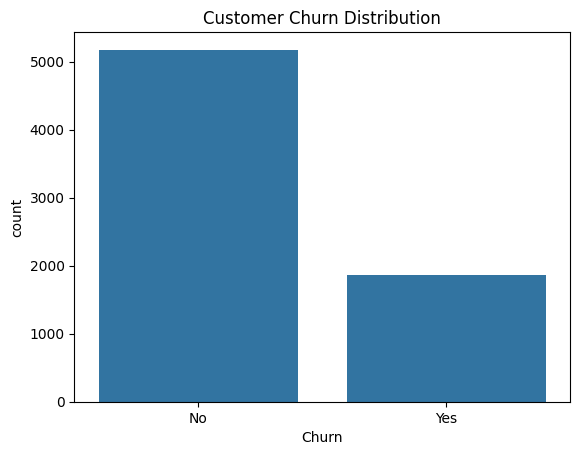

In [14]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

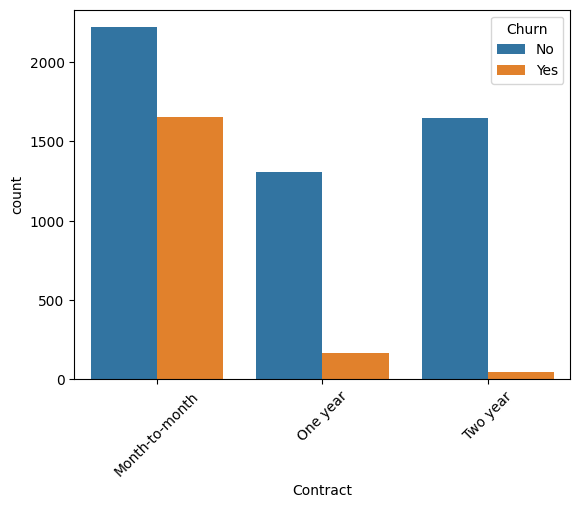

In [15]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

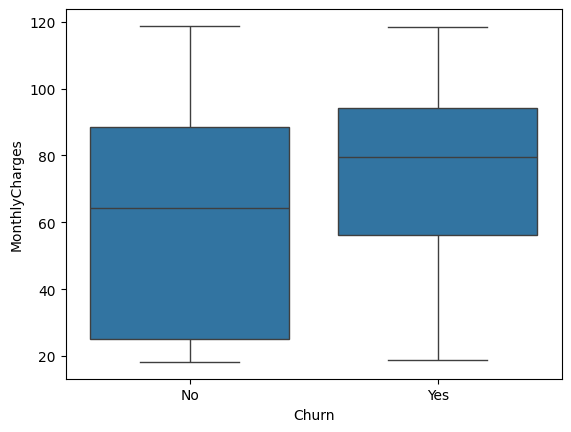

In [16]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

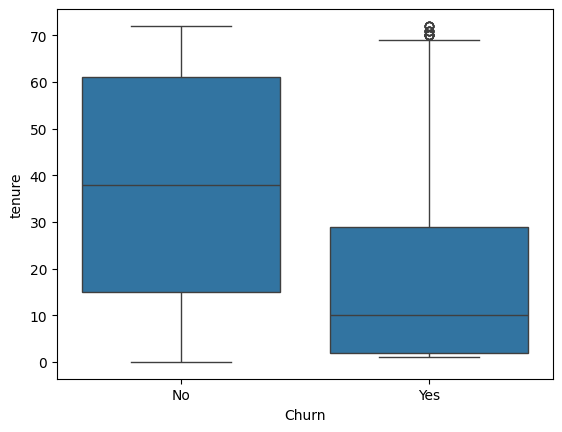

In [17]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

In [18]:
df["TotalSpend"] = df["MonthlyCharges"] * df["tenure"]

In [19]:
df.replace({"Yes":1, "No":0}, inplace=True)

/tmp/ipykernel_559/3520732665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Yes":1, "No":0}, inplace=True)


In [21]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [26]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.8176011355571328
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [28]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7920511000709723
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [29]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.7977288857345636
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.64      0.53      0.58       373

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:14:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


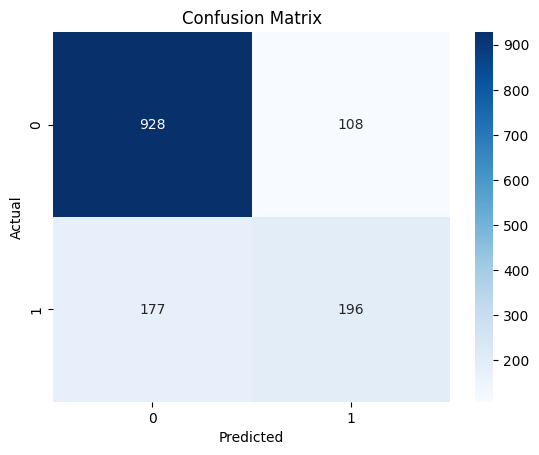

In [30]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

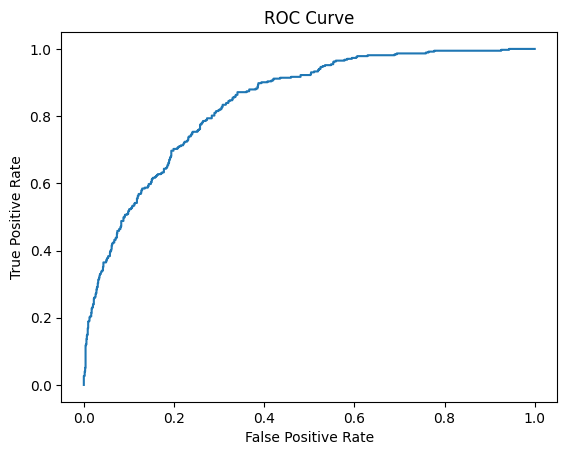

In [31]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [32]:
roc_auc_score(y_test, y_prob)

np.float64(0.8406507809993067)

In [33]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance.sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
14,Contract,0.314011
7,InternetService,0.284907
8,OnlineSecurity,0.049443
5,PhoneService,0.036654
11,TechSupport,0.033714
4,tenure,0.028688
6,MultipleLines,0.022860
15,PaperlessBilling,0.020314
17,MonthlyCharges,0.020016
13,StreamingMovies,0.019346


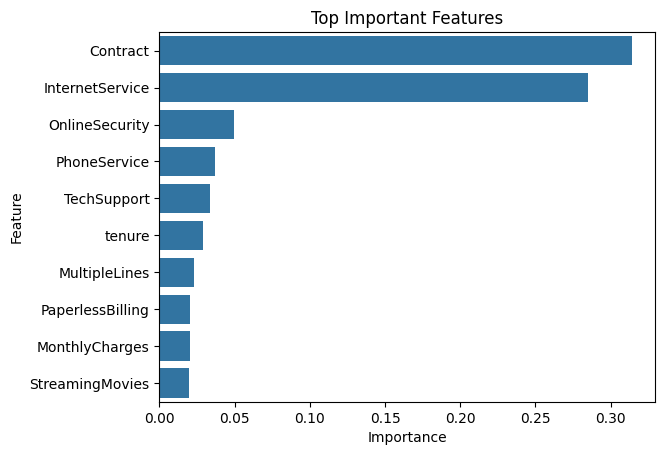

In [34]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.sort_values(by="Importance", ascending=False).head(10)
)

plt.title("Top Important Features")
plt.show()

In [35]:
with open("churn_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

In [36]:
with open("churn_model.pkl", "rb") as file:
    model = pickle.load(file)

In [37]:
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

print("Churn Prediction:", prediction)

Churn Prediction: [1]


# Customer Churn Prediction using Machine Learning

Customer churn is a major challenge for subscription-based businesses such as telecom companies. When customers stop using a service, it leads to revenue loss and increased customer acquisition costs.

This project aims to analyze customer behavior and build a machine learning model that can predict whether a customer is likely to churn.

By identifying customers who are at high risk of leaving, companies can implement targeted retention strategies such as personalized offers, improved service quality, or loyalty programs.

The main objectives of this project are:

• Analyze customer behavior and identify factors influencing churn  
• Perform exploratory data analysis to discover patterns in customer data  
• Build machine learning models to predict customer churn  
• Evaluate model performance using appropriate metrics  
• Provide business insights to help reduce customer churn

# Dataset Overview

The dataset used in this project is the Telco Customer Churn dataset.

It contains information about telecom customers, including demographics, account information, and the services they use.

Each row represents a unique customer, and the dataset includes various attributes that may influence customer churn.

Key features in the dataset include:

• **Customer Demographics**
    - Gender
    - Senior Citizen
    - Partner
    - Dependents

• **Service Information**
    - Phone Service
    - Internet Service
    - Online Security
    - Streaming Services

• **Account Information**
    - Contract Type
    - Payment Method
    - Monthly Charges
    - Total Charges
    - Tenure

• **Target Variable**
    - Churn (Yes / No)

The goal of this project is to predict the **Churn** variable.

# Business Problem

Customer retention is significantly cheaper than acquiring new customers.

When customers leave a service, companies experience:

• Revenue loss  
• Increased marketing costs  
• Lower customer lifetime value  

By predicting which customers are likely to churn, businesses can proactively take actions such as:

• Offering discounts  
• Improving customer support  
• Providing personalized services  

Machine learning enables businesses to identify churn patterns and make data-driven decisions to reduce customer attrition.

# Loading the Dataset

In this step, we load the dataset into Python using Pandas.

We will inspect the dataset structure, understand the available features, and ensure the data has been loaded correctly.

# Understanding the Data

Before building machine learning models, it is important to understand the dataset.

We will examine:

• Dataset shape (number of rows and columns)  
• Data types of each feature  
• Missing values  
• Distribution of the target variable

Understanding the dataset helps identify potential data quality issues and informs the preprocessing steps required before model training.

# Data Cleaning

Real-world datasets often contain inconsistencies, missing values, or incorrect data types.

In this step, we perform the following operations:

• Remove unnecessary columns such as customer ID  
• Convert TotalCharges to numeric format  
• Handle missing values  
• Ensure the dataset is suitable for machine learning algorithms

# Exploratory Data Analysis

Exploratory Data Analysis helps us uncover patterns, relationships, and trends within the dataset.

In this section, we analyze how different features relate to customer churn.

Key questions we explore include:

• Are customers with shorter tenure more likely to churn?  
• Does contract type influence churn rates?  
• Do customers with higher monthly charges churn more often?  
• How do service subscriptions affect churn behavior?

Visualizations allow us to identify meaningful insights that can guide feature engineering and model building.

# Key Insights from Exploratory Analysis

From the visual analysis, several patterns emerge:

1. Customers with **month-to-month contracts** show a higher churn rate compared to long-term contracts.

2. Customers with **shorter tenure** are more likely to churn, suggesting early engagement is critical.

3. Customers with **higher monthly charges** tend to churn more frequently.

4. Lack of services such as **online security and tech support** appears to be associated with higher churn rates.

These insights indicate that pricing strategies, service quality, and contract types significantly influence customer retention.

# Feature Engineering

Feature engineering involves creating new features that improve the predictive power of machine learning models.

In this project, we create a new feature:

**TotalSpend = MonthlyCharges × Tenure**

This feature represents the estimated total amount spent by a customer during their subscription period.

Feature engineering helps capture additional business insights that may not be directly present in the original dataset.

# Data Preprocessing

Machine learning models require numerical inputs.

Therefore, categorical variables must be converted into numerical form.

The preprocessing steps include:

• Encoding categorical variables using Label Encoding  
• Splitting the dataset into training and testing sets  
• Scaling numerical features to ensure consistent model performance

# Machine Learning Models

We train multiple machine learning models to compare their performance in predicting customer churn.

The models used in this project include:

• Logistic Regression – A baseline classification model  
• Random Forest – An ensemble learning algorithm  
• XGBoost – A powerful gradient boosting model widely used in industry

Using multiple models allows us to identify the algorithm that best captures the patterns in the dataset.

# Model Evaluation

To evaluate the performance of our models, we use several classification metrics:

• Accuracy – Overall correctness of predictions  
• Precision – How many predicted churn cases were actually churn  
• Recall – Ability to detect churn customers  
• F1 Score – Balance between precision and recall  
• ROC-AUC Score – Overall model discrimination capability

These metrics help determine how effectively the model identifies customers who are likely to churn.

# Feature Importance Analysis

Understanding which features influence the model’s predictions is crucial.

Feature importance analysis helps identify the most significant factors contributing to customer churn.

Typical influential features include:

• Contract type  
• Tenure  
• Monthly charges  
• Internet service type  
• Total spend

These insights can guide businesses in designing strategies to improve customer retention.
# Business Recommendations

Based on the analysis and model results, the following strategies can help reduce customer churn:

1. Encourage customers to switch from month-to-month contracts to long-term plans.

2. Improve onboarding experiences for new customers to reduce early churn.

3. Provide bundled services such as online security and technical support.

4. Offer targeted promotions to customers with high monthly charges.

Implementing these strategies can significantly improve customer retention and increase customer lifetime value.

# Conclusion

In this project, we analyzed telecom customer data and developed machine learning models to predict customer churn.

Through exploratory analysis, we identified key factors influencing churn behavior. The machine learning models demonstrated the ability to classify customers who are likely to leave the service.

By leveraging predictive analytics, businesses can proactively address customer dissatisfaction and implement retention strategies that improve long-term profitability.


# Model Explainability using SHAP

Machine learning models such as XGBoost can produce highly accurate predictions, but they often behave like "black boxes", meaning it can be difficult to understand how they arrive at their decisions.

To address this challenge, we use **SHAP (SHapley Additive exPlanations)**.

SHAP helps explain the contribution of each feature to a model's prediction. It provides both global and local explanations:

• **Global explanation** – Which features are most important overall  
• **Local explanation** – Why a specific prediction was made for a particular customer

Using SHAP allows businesses to understand the key factors driving customer churn and develop targeted retention strategies.

In [38]:
!pip install shap

In [39]:
import shap

In [40]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

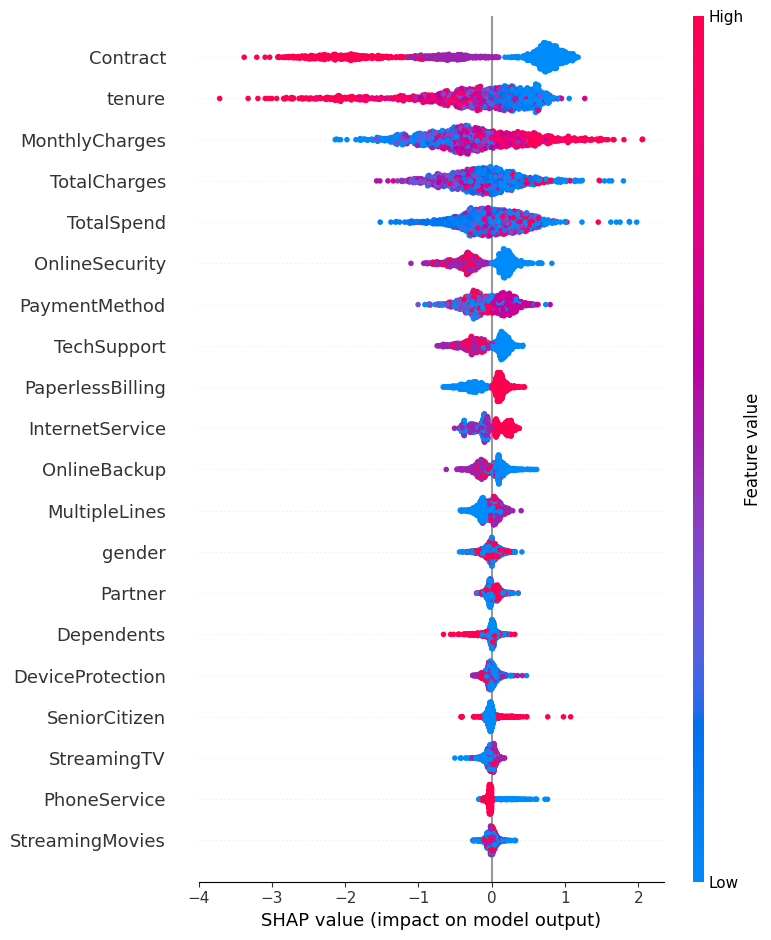

In [41]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

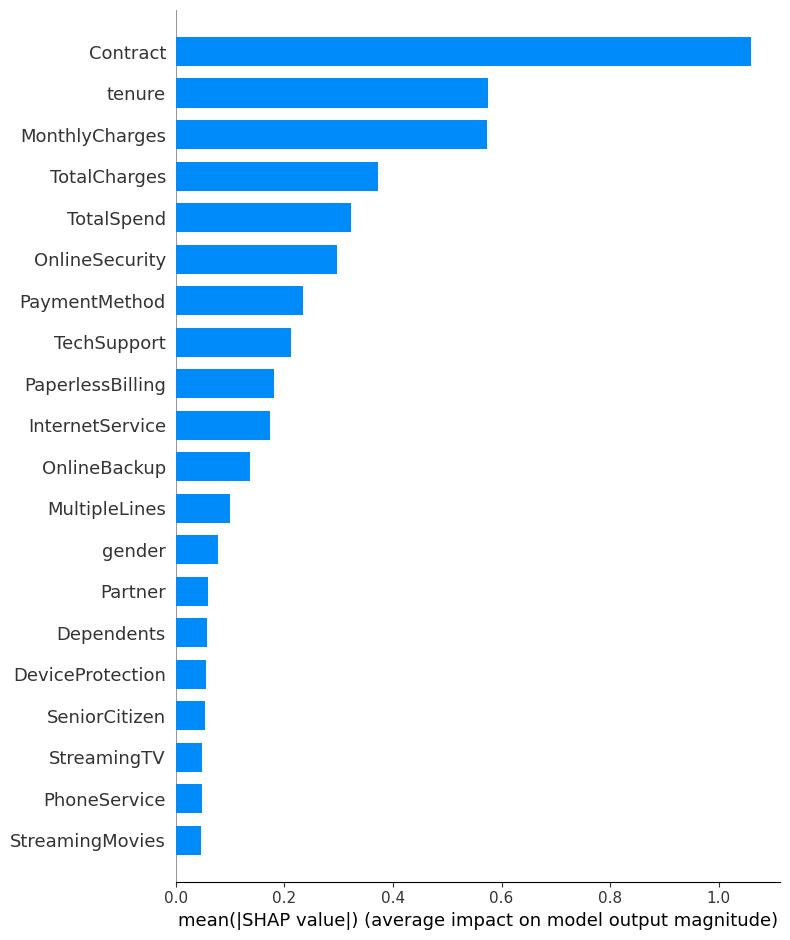

In [42]:
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X.columns)

In [43]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test[0],
    feature_names=X.columns
)

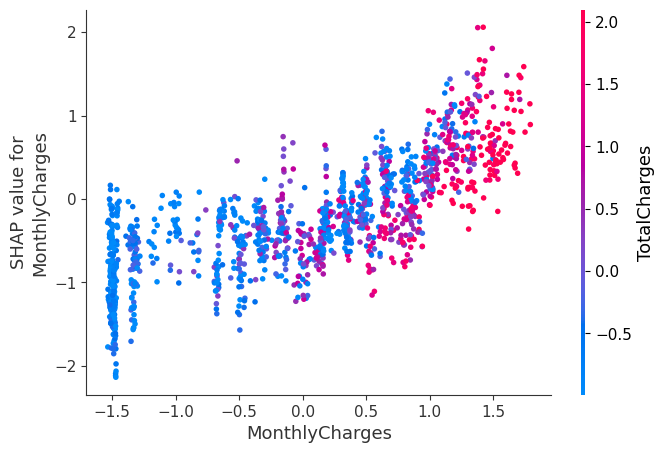

In [44]:
shap.dependence_plot("MonthlyCharges", shap_values, X_test, feature_names=X.columns)

# Insights from SHAP Analysis

SHAP analysis highlights the most influential factors affecting customer churn.

Key observations include:

• Customers with **month-to-month contracts** are more likely to churn.  
• **Higher monthly charges** increase the probability of churn.  
• Customers with **shorter tenure** show higher churn rates.  
• Customers lacking **additional services such as online security or tech support** tend to churn more often.

These insights allow businesses to design proactive strategies to retain high-risk customers.